In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailismailtijjani/naira-nigerian-currency-dataset")

print("Path to dataset files:", path)

100%|██████████| 179M/179M [00:02<00:00, 80.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ismailismailtijjani/naira-nigerian-currency-dataset/versions/1


In [ ]:
import os
import tensorflow as tf

# Define the full path to the 'NAIRA DATASET' directory
dataset_path = os.path.join(path, 'NAIRA DATASET')

# List the contents of the 'NAIRA DATASET' directory
print(os.listdir(dataset_path))

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'Train'),
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'val'),
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'Test'),
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print('\nDatasets loaded successfully.')

# Data Augmentation and Rescaling

# Rescaling layer to normalize pixel values from [0, 255] to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# Apply rescaling to all datasets
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Data augmentation for the training set
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    tf.keras.layers.RandomContrast(factor=0.2)
])

# Apply data augmentation to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print('Data preprocessing and augmentation complete.')

['Test', 'val', 'Train']
Found 1736 files belonging to 8 classes.
Found 216 files belonging to 8 classes.
Found 90 files belonging to 8 classes.

Datasets loaded successfully.
Data preprocessing and augmentation complete.


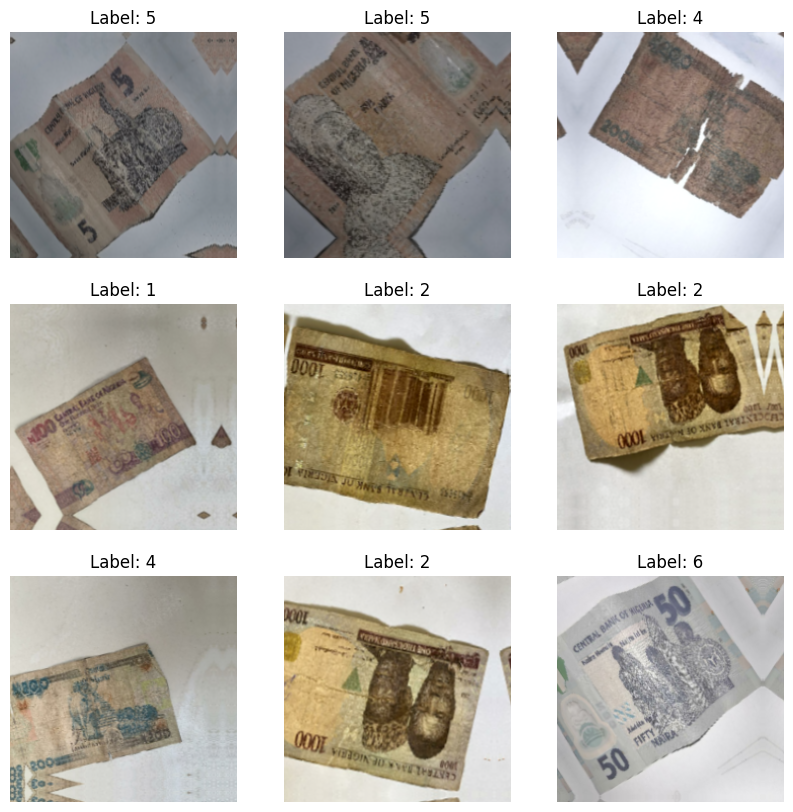